In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from compressibleSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [16]:
nx = 512
dim = 2
L = 2
n_h = 4

rho0 = 1

octaves = 4
lacunarity = 2
persistence = 0.5
baseFrequency = 2
tileable = True
kind = 'perlin'
seed = 45906734
obstacle = False


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'octaves': octaves,
    'lacunarity': lacunarity,
    'persistence': persistence,
    'baseFrequency': baseFrequency,
    'tileable': tileable,
    'kind': kind,
    'seed': seed,
    'obstacle': obstacle
}

In [17]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros(dim, device=device, dtype=dtype)
domain.max = torch.ones(dim, device=device, dtype=dtype) * 2 * np.pi

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False


In [21]:
compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)
print(f"Number of particles: {compressibleSystem.state.positions.shape[0]}")

Number of particles: 262144


In [22]:
nu_inviscid = alphaToNu(schemeConfig.diffusionParams.inviscidAlpha, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha_effective = nuToAlpha(schemeConfig.diffusionParams.viscidNu, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
print(f"nu_inviscid: {nu_inviscid}, alpha_effective: {alpha_effective}")

nu_inviscid: 0.0006135923322290182, alpha_effective: 0.016297465719091783


In [23]:
compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 128, jitterAmount = 0.5)

In [24]:


velocities = sampleDivergenceFreeNoise(compressibleSystem.state, domain, config, schemeConfig, nx * 2, 
                                    octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)
compressibleSystem.state.velocities[:] = velocities

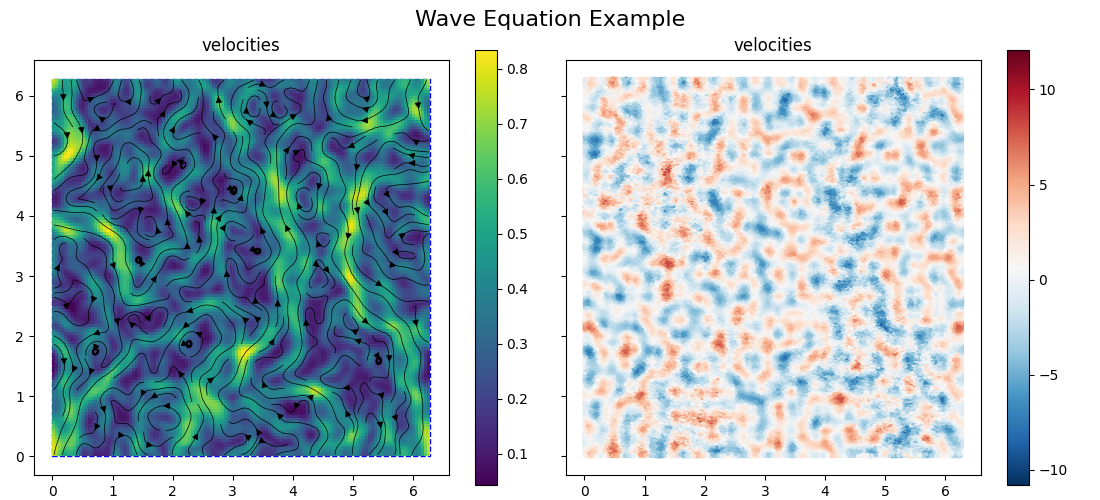

In [25]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 128,
                streamLines = True
            ),
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.x,
            plottingOperation = OperationProperties(
                operation = WarpOperation.Curl,
                kernel = config.kernel,
                supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
            ),
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [26]:
runningState = compressibleSystem.initializeNewState()
from compressibleSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0004, device='cuda:0')


In [27]:

caseName = 'randomVelocityField'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [32]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap, CyclicColorMap
markerSize = 1
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.UIDs,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 1024,
            ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = CyclicColorMap.twilight,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)


RFBOutputContext()

In [33]:
runningState = compressibleSystem.initializeNewState()
ke = torch.sum(0.5 * runningState.state.densities * torch.sum(runningState.state.velocities**2, dim=1)) / torch.sum(runningState.state.densities)

schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.nu = 0.01

In [34]:

t_limit = 10.0
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.UIDs,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/24224 [00:00<?, ?it/s]

In [15]:

# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'frame_num': i,
# }))

In [35]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/randomVelocityField/output.mp4'